In [1]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt

In [2]:
basePath       = '../sims.TNG/TNG50-3/output/'
snapshot_num   = 59          # alterar para z = 0, z = 0.5 ou z = 0.7
zred           = 0.7

radius_cut     = 300.0       # kpc/h — raio máximo de análise
icl_limit      = 5           # múltiplo do R_half para separar ICL

radii_bins     = np.arange(0, radius_cut + 10, 10)  # bins de 10 kpc/h
radius_centers = (radii_bins[1:] + radii_bins[:-1]) / 2.0

Z_sun = 0.0127   # metalicidade solar (fração de massa)

In [3]:
halos = il.groupcat.loadHalos(basePath, snapshot_num,
                              fields=['GroupFirstSub', 'Group_M_Mean200', 'GroupPos',
                                      'Group_R_Mean200', 'GroupStarMetallicity'])

# SubhaloStarMetallicity: metalicidade média de cada subhalo/galáxia
subhalos = il.groupcat.loadSubhalos(basePath, snapshot_num,
                                    fields=['SubhaloFlag', 'SubhaloPos', 'SubhaloHalfmassRad',
                                            'SubhaloMass', 'SubhaloStarMetallicity'])

# GFM_Metallicity: fração de massa em metais — valor direto, sem proxy
stars = il.snapshot.loadSubset(basePath, snapshot_num, 'stars', 
                               fields=['Coordinates', 'Masses',
                                       'GFM_Metallicity', 'GFM_StellarFormationTime'])

In [4]:
# SELECIONAR HALOS MASSIVOS  log10(M200) > 13.7

ind, = np.where(halos['Group_M_Mean200'] > 5.0e3)
print(f"Halos selecionados: {len(ind)}")
print(f"log10(M200) = {np.log10(halos['Group_M_Mean200'][ind]) + 10.0}")

# Metalicidade estelar do halo em [Z_sun] — já normalizada pelo TNG
print(f"GroupStarMetallicity [Z_sun] = {halos['GroupStarMetallicity'][ind]}")

Halos selecionados: 1
log10(M200) = [13.8532295]
GroupStarMetallicity [Z_sun] = [0.01791112]


In [5]:
# LOOP PRINCIPAL: POR HALO

all_logZ_icl    = []
all_dist_icl    = []
all_mass_icl    = []

all_logZ_noicl  = []
all_dist_noicl  = []
all_mass_noicl  = []

for i in ind[:1]:   # mudar para ind[:N] se for usar N halos

    print(f"\n--- Processando halo {i} ---")
    print(f"  GroupStarMetallicity = {halos['GroupStarMetallicity'][i]:.4f} Z_sun")
    halo_cent = halos['GroupPos'][i, :]

    # Distância dos subhalos ao centro do halo
    subhalo_dist = np.sqrt(
        (subhalos['SubhaloPos'][:, 0] - halo_cent[0])**2 +
        (subhalos['SubhaloPos'][:, 1] - halo_cent[1])**2 +
        (subhalos['SubhaloPos'][:, 2] - halo_cent[2])**2)
    subhalo_dist_ind, = np.where(subhalo_dist < radius_cut + 100)

    # Distância das estrelas ao centro do halo
    dist_stars = np.sqrt(
        (stars['Coordinates'][:, 0] - halo_cent[0])**2 +
        (stars['Coordinates'][:, 1] - halo_cent[1])**2 +
        (stars['Coordinates'][:, 2] - halo_cent[2])**2)

    dist_ind, = np.where((dist_stars < radius_cut) & (dist_stars > 5))
    print(f"  Estrelas no raio de análise: {len(dist_ind)}")

    # Metalicidade em log10(Z/Z_sun) 
    # Excluir partículas de vento (GFM_StellarFormationTime < 0)
    form_time = stars['GFM_StellarFormationTime'][dist_ind]
    valid_mask = form_time > 0

    Z_raw   = stars['GFM_Metallicity'][dist_ind]
    Z_clip  = np.clip(Z_raw, 1e-6, None)          # evitar log(0)
    logZ    = np.log10(Z_clip / Z_sun)             # em unidades de Z_sun
    logZ[~valid_mask] = np.nan                     # mascarar ventos

    # Separação ICL vs não-ICL
    subhalo_star_distance_norm = np.ones(len(dist_ind))

    for jj in subhalo_dist_ind[1:]:
        subhalo_x = subhalos['SubhaloPos'][jj, 0]
        subhalo_y = subhalos['SubhaloPos'][jj, 1]
        subhalo_z = subhalos['SubhaloPos'][jj, 2]
        r_half    = subhalos['SubhaloHalfmassRad'][jj]

        if r_half <= 0:
            continue

        d = np.sqrt(
            (stars['Coordinates'][dist_ind, 0] - subhalo_x)**2 +
            (stars['Coordinates'][dist_ind, 1] - subhalo_y)**2 +
            (stars['Coordinates'][dist_ind, 2] - subhalo_z)**2
        ) / (r_half * icl_limit)

        inside, = np.where(d < 1.0)
        subhalo_star_distance_norm[inside] = 0

    ind_icl,    = np.where(subhalo_star_distance_norm > 0.5)
    ind_no_icl, = np.where(subhalo_star_distance_norm < 0.5)

    print(f"  Estrelas ICL:     {len(ind_icl)}")
    print(f"  Estrelas não-ICL: {len(ind_no_icl)}")

    # Guardar arrays
    # ICL
    valid_icl = valid_mask[ind_icl]
    all_dist_icl.append(dist_stars[dist_ind[ind_icl]][valid_icl])
    all_logZ_icl.append(logZ[ind_icl][valid_icl])
    all_mass_icl.append(stars['Masses'][dist_ind[ind_icl]][valid_icl])

    # não-ICL
    valid_noicl = valid_mask[ind_no_icl]
    all_dist_noicl.append(dist_stars[dist_ind[ind_no_icl]][valid_noicl])
    all_logZ_noicl.append(logZ[ind_no_icl][valid_noicl])
    all_mass_noicl.append(stars['Masses'][dist_ind[ind_no_icl]][valid_noicl])


--- Processando halo 0 ---
  GroupStarMetallicity = 0.0179 Z_sun
  Estrelas no raio de análise: 172803
  Estrelas ICL:     66505
  Estrelas não-ICL: 106298


In [6]:
# CONCATENAR (no caso de múltiplos halos)

dist_icl   = np.concatenate(all_dist_icl)
logZ_icl   = np.concatenate(all_logZ_icl)
mass_icl   = np.concatenate(all_mass_icl)

dist_noicl = np.concatenate(all_dist_noicl)
logZ_noicl = np.concatenate(all_logZ_noicl)
mass_noicl = np.concatenate(all_mass_noicl)

In [7]:
# BINAGEM RADIAL: média ponderada pela massa

def weighted_binned_mean(dist, values, weights, bins, min_part=5):
    """Média ponderada pela massa em cada bin radial."""
    bin_mean = np.full(len(bins) - 1, np.nan)
    bin_std  = np.full(len(bins) - 1, np.nan)

    for k in range(len(bins) - 1):
        mask = (dist >= bins[k]) & (dist < bins[k+1])
        if mask.sum() < min_part:
            continue
        w = weights[mask]
        v = values[mask]
        bin_mean[k] = np.average(v, weights=w)
        variance    = np.average((v - bin_mean[k])**2, weights=w)
        bin_std[k]  = np.sqrt(variance)

    return bin_mean, bin_std

print("Calculando perfis radiais de metalicidade...")

logZ_mean_icl,   logZ_std_icl   = weighted_binned_mean(
    dist_icl,   logZ_icl,   mass_icl,   radii_bins)

logZ_mean_noicl, logZ_std_noicl = weighted_binned_mean(
    dist_noicl, logZ_noicl, mass_noicl, radii_bins)

Calculando perfis radiais de metalicidade...


Gráfico salvo em: metallicity_profile_icl_limit5_z0.7.png


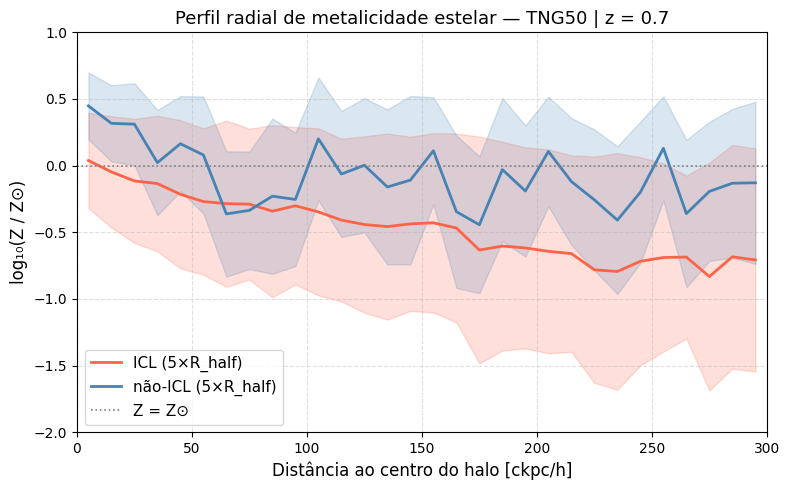

In [8]:
# PLOT

fig, ax = plt.subplots(figsize=(8, 5))

r = radius_centers

# ICL
mask_icl = np.isfinite(logZ_mean_icl)
ax.plot(r[mask_icl], logZ_mean_icl[mask_icl],
        color='tomato', lw=2, label=f'ICL ({icl_limit}×R_half)')
ax.fill_between(r[mask_icl], logZ_mean_icl[mask_icl] - logZ_std_icl[mask_icl],
                logZ_mean_icl[mask_icl] + logZ_std_icl[mask_icl], color='tomato', alpha=0.2)

# não-ICL
mask_noicl = np.isfinite(logZ_mean_noicl)
ax.plot(r[mask_noicl], logZ_mean_noicl[mask_noicl],
        color='steelblue', lw=2, label=f'não-ICL ({icl_limit}×R_half)')
ax.fill_between(r[mask_noicl], logZ_mean_noicl[mask_noicl] - logZ_std_noicl[mask_noicl],
                logZ_mean_noicl[mask_noicl] + logZ_std_noicl[mask_noicl], color='steelblue', alpha=0.2)

# Linha de referência: Z = Z_sun
ax.axhline(0.0, color='gray', linestyle=':', lw=1.2, label='Z = Z⊙')

ax.set_xlabel('Distância ao centro do halo [ckpc/h]', fontsize=12)
ax.set_ylabel('log₁₀(Z / Z⊙)', fontsize=12)
ax.set_title(f'Perfil radial de metalicidade estelar — TNG50 | z = {zred}', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, radius_cut)
ax.set_ylim(-2, 1)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'metallicity_profile_icl_limit{icl_limit}_z{zred}.png', dpi=150)
print(f"Gráfico salvo em: metallicity_profile_icl_limit{icl_limit}_z{zred}.png")
plt.show()

Hexbin salvo em: metallicity_hexbin_icl_limit5_z0.7.png


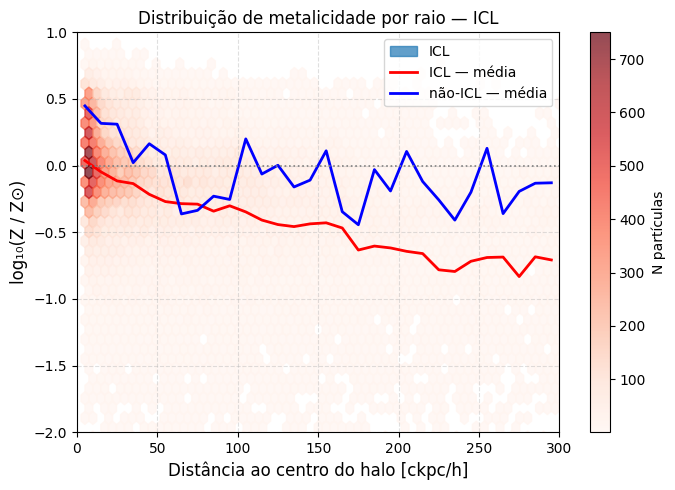

In [9]:
# Diagrama Z vs Idade: quebrando a degenerescência
# Plota a nuvem de partículas no espaço (idade, Z) separando ICL de não-ICL
# Isso mostra visualmente onde a degenerescência ocorre e quão distintas são as populações.

# Idade do universo
from astropy.cosmology import Planck15
import astropy.units as u
age_universe_gyr = Planck15.age(zred).to(u.Gyr).value
age_universe_gyr

# Calcular idades para ICL e não-ICL a partir dos índices já filtrados

N_sample = 50000

if len(logZ_icl) > N_sample:
    idx_s = np.random.choice(len(logZ_icl), N_sample, replace=False)
else:
    idx_s = np.arange(len(logZ_icl))

fig2, ax2 = plt.subplots(figsize=(7, 5))

# Hexbin ICL
hb = ax2.hexbin(dist_icl[idx_s], logZ_icl[idx_s], gridsize=60, cmap='Reds', mincnt=1, alpha=0.7, label='ICL')

plt.colorbar(hb, ax=ax2, label='N partículas')

ax2.plot(r[mask_icl],   logZ_mean_icl[mask_icl], 'r-', lw=2, label='ICL — média')
ax2.plot(r[mask_noicl], logZ_mean_noicl[mask_noicl], 'b-', lw=2, label='não-ICL — média')
ax2.axhline(0.0, color='gray', linestyle=':', lw=1.2)

ax2.set_xlabel('Distância ao centro do halo [ckpc/h]', fontsize=12)
ax2.set_ylabel('log₁₀(Z / Z⊙)', fontsize=12)
ax2.set_title('Distribuição de metalicidade por raio — ICL', fontsize=12)
ax2.legend(fontsize=10)
ax2.set_xlim(0, radius_cut)
ax2.set_ylim(-2, 1)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'metallicity_hexbin_icl_limit{icl_limit}_z{zred}.png', dpi=150)
print(f"Hexbin salvo em: metallicity_hexbin_icl_limit{icl_limit}_z{zred}.png")
plt.show()